In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import figurefirst as fifi
###

from splitflow.PlotUtilities import *
from splitflow.FeatureFunctions import *


plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']

plt.rcParams['text.usetex'] = False
#plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'


Using device: cpu


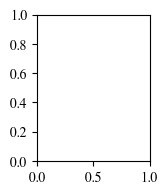

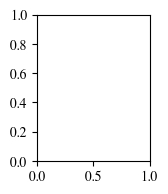

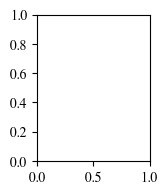

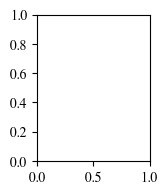

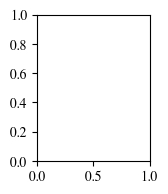

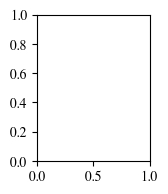

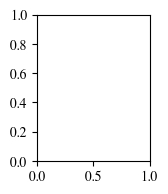

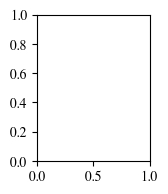

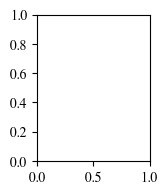

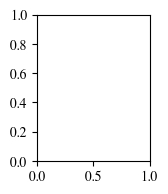

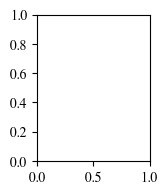

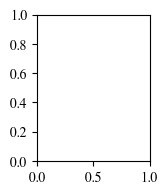

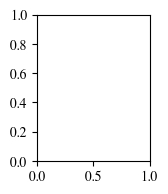

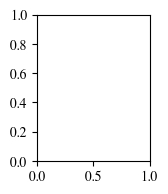

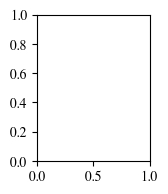

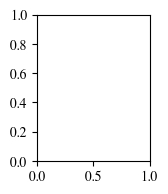

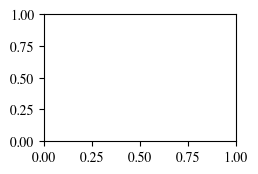

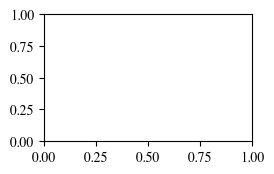

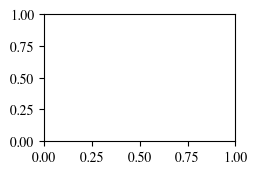

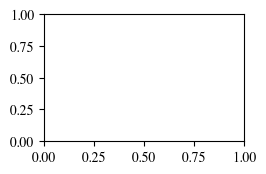

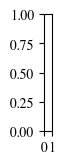

In [2]:
layout = fifi.svg_to_axes.FigureLayout('supp_all_trajectories_altitude_sorted_template.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])




# Bottom Half On

In [3]:
bottom_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_bottom_laminar_09092024.hdf')


FileNotFoundError: File ../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_bottom_laminar_09092024.hdf does not exist

In [4]:
bottom_on_df['ground speed'] = np.sqrt(bottom_on_df.xvel**2 + bottom_on_df.yvel**2)


In [6]:
df_flash_bottom_on = bottom_on_df.groupby("obj_id_unique").filter(lambda d: (np.any(d.duplicate_obj_id_bool)==False) and (np.any(d.Flash_bool)==True) and (np.all(d.duration>0)) and (d['z'].min() >= -0.01))
df_sham_bottom_on = bottom_on_df.groupby("obj_id_unique").filter(lambda d: (np.all(d.duration==0)) and (d['z'].min() >= -0.01) and np.all(d[d['time stamp']==0].x.between(-.35,0.35)) and np.all(d[d['time stamp']==0]['y'].between(-0.1,0.1)) and np.all(d[d['time stamp']==0]['z'].between(0.1,0.35)))



# Top Half On

In [9]:
top_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_top_laminar_09082024.hdf')

In [10]:
top_on_df['ground speed'] = np.sqrt(top_on_df.xvel**2 + top_on_df.yvel**2)

In [12]:
df_flash_top_on = top_on_df.groupby("obj_id_unique").filter(lambda d: (np.any(d.duplicate_obj_id_bool)==False) and (np.any(d.Flash_bool)==True) and (np.all(d.duration>0)) and (d['z'].min() >= -0.01))
df_sham_top_on = top_on_df.groupby("obj_id_unique").filter(lambda d: (np.all(d.duration==0)) and (d['z'].min() >= -0.01) and np.all(d[d['time stamp']==0].x.between(-.35,0.35)) and np.all(d[d['time stamp']==0]['y'].between(-0.1,0.1)) and np.all(d[d['time stamp']==0]['z'].between(0.1,0.35)))



# Altitude Organized Histplot of All Trajs

In [15]:
# pd.concat([ sham_up,  sham_low]).copy()
def traj_sorter(column):
    """Sort function"""
    
    meanzlist = dum_df[dum_df['time stamp'].between(0,675)].groupby('obj_id_unique').z.mean().sort_values(ascending=True).index
    locs = {traj: order for order, traj in enumerate(meanzlist)}
    return column.map(locs)


## Bottom Fans On

## Flash

In [16]:
df_flash = df_flash_bottom_on
df_flash_triggers = df_flash[df_flash.obj_id_unique.isin(df_flash[df_flash.Trigger_bool==True].obj_id_unique.unique())]
df_flash_triggers = df_flash_triggers.groupby('obj_id_unique').filter(lambda d: d['time stamp'].max()>=3000)
df_flash_triggers['abs_smooth_ang_vel'] = np.abs(df_flash_triggers.smoothed_angvel_params_128)

In [17]:
dum_df = df_flash_triggers
df_flash_sorted_by_z = dum_df.sort_values(by='obj_id_unique', key=traj_sorter)
df_flash_sorted_by_z['adj_heading'] = np.abs(df_flash_sorted_by_z['heading'].copy())



In [18]:
#fix index for plotting
df_flash_sorted_by_z['new_index']=0
j=1
catch =[]
means = []
for i in df_flash_sorted_by_z.obj_id_unique.unique():
    dum = df_flash_sorted_by_z[ df_flash_sorted_by_z.obj_id_unique==i]
    dum['new_index'] = j 
    #print('index:'+ str(dum['new_index'].iloc[0]) + ', mean z:' + str(np.mean(dum[dum['time stamp'].between(0,675)].z)) )
    j+=1
    catch.append(dum)
    means.append(np.mean(dum[dum['time stamp'].between(0,675)].z))
df_flash_sorted_by_z=pd.concat(catch)   


/tmp/ipykernel_7458/1160298079.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dum['new_index'] = j


/tmp/ipykernel_7458/3970373057.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right',)


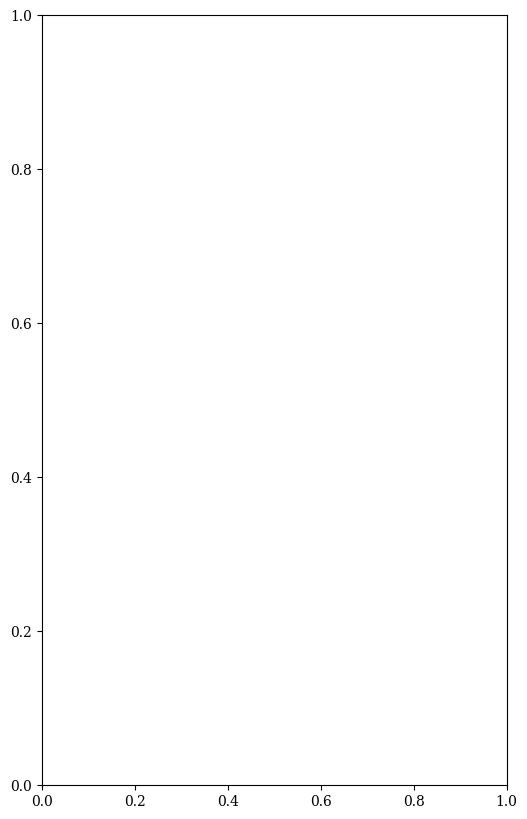

In [19]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='z')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('E1', 'e1')]

pc = ax.pcolormesh(test1, vmin=0, vmax=0.5, rasterized=True) 
clb=fig.colorbar(pc, location='right',)

#clb.set_ticks([0,0.1,.3.14], labels=['','upwind','downwind'],rotation=270)

#clb.ax.set_title('Altitude (m)', loc='right')

ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','','3'])
#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)
#ax.set_xlabel('Time, s')
fifi.mpl_functions.set_fontsize(ax, 6)

#
layout.append_figure_to_layer(layout.figures['E1'], 'E1', cleartarget=True)

/tmp/ipykernel_7458/3635840541.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


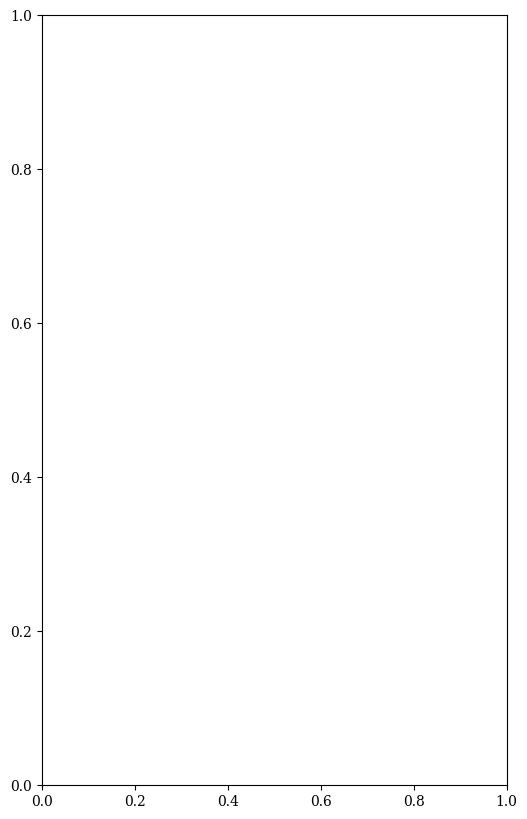

In [20]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='adj_heading')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('E2', 'e2')]

pc = ax.pcolormesh(test1, vmin=0, vmax=np.pi,   rasterized=True)
clb=fig.colorbar(pc, location='right')
clb.set_ticks([0,(np.pi/2),3.14], labels=['0','','$\pi$'])
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''],)
fifi.mpl_functions.set_fontsize(ax, 6)



layout.append_figure_to_layer(layout.figures['E2'], 'E2', cleartarget=True)

/tmp/ipykernel_7458/1244757588.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


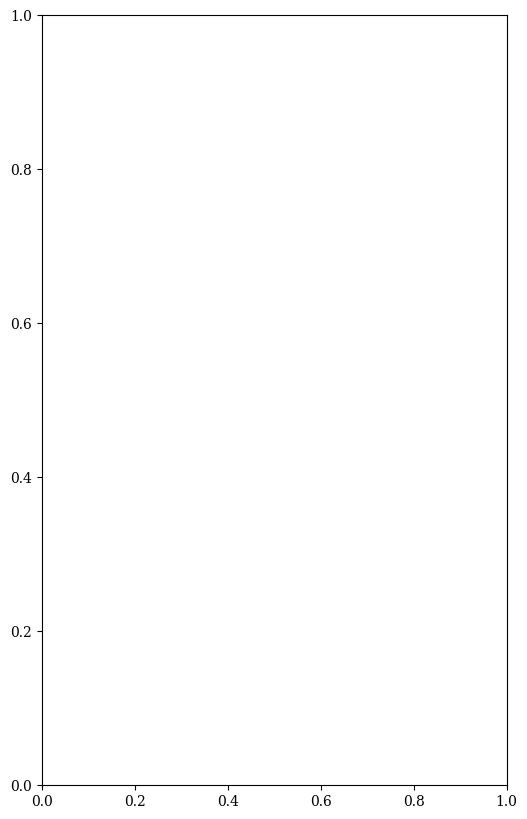

In [21]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='abs_smooth_ang_vel')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('E3', 'e3')]

pc = ax.pcolormesh(test1, vmin=0,vmax=20,  rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,3.14], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['E3'], 'E3', cleartarget=True)


/tmp/ipykernel_7458/2440955640.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


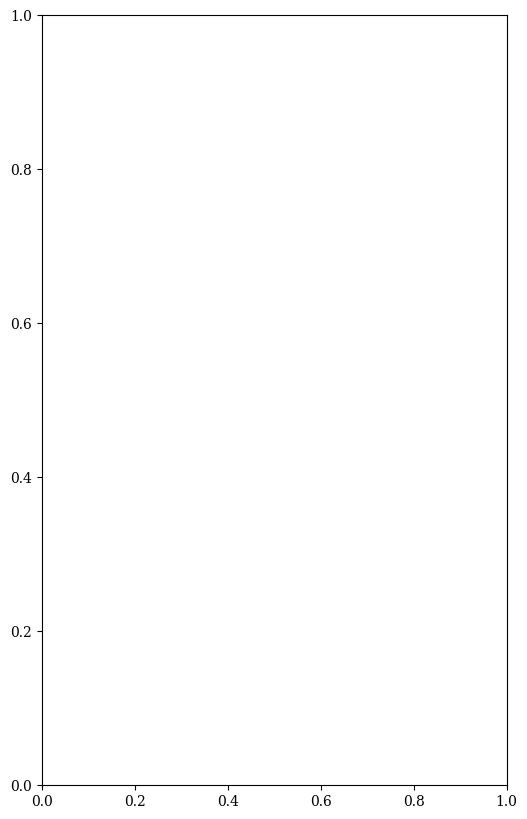

In [22]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='ground speed')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('E4', 'e4')]

pc = ax.pcolormesh(test1, vmin=0, vmax=1,   rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,1], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350], )
ax.set_xticklabels(['-0.5','0.0','0.68', '1','2','3'], rotation=45)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.set_ylabel('Trajectory Number')
ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['E4'], 'E4', cleartarget=True)

## Shams

In [23]:
df_sham_triggers = df_sham_bottom_on
#df_sham_triggers = df_sham[df_sham.obj_id_unique.isin(df_sham[df_sham.Trigger_bool==True].obj_id_unique.unique())]
df_sham_triggers = df_sham_triggers.groupby('obj_id_unique').filter(lambda d: d['time stamp'].max()>=3000)
df_sham_triggers['abs_smooth_ang_vel'] = np.abs(df_sham_triggers.smoothed_angvel_params_128)

In [24]:
dum_df = df_sham_triggers
df_sham_sorted_by_z = dum_df.sort_values(by='obj_id_unique', key=traj_sorter)
df_sham_sorted_by_z['adj_heading'] = np.abs(df_sham_sorted_by_z['heading'].copy())



In [25]:
#fix index for plotting
df_sham_sorted_by_z['new_index']=0
j=1
catch =[]
means = []
for i in df_sham_sorted_by_z.obj_id_unique.unique():
    dum = df_sham_sorted_by_z[ df_sham_sorted_by_z.obj_id_unique==i]
    dum['new_index'] = j 
    #print('index:'+ str(dum['new_index'].iloc[0]) + ', mean z:' + str(np.mean(dum[dum['time stamp'].between(0,675)].z)) )
    j+=1
    catch.append(dum)
    means.append(np.mean(dum[dum['time stamp'].between(0,675)].z))
df_sham_sorted_by_z=pd.concat(catch)    

/tmp/ipykernel_7458/623801160.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dum['new_index'] = j


/tmp/ipykernel_7458/3660692075.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right',)


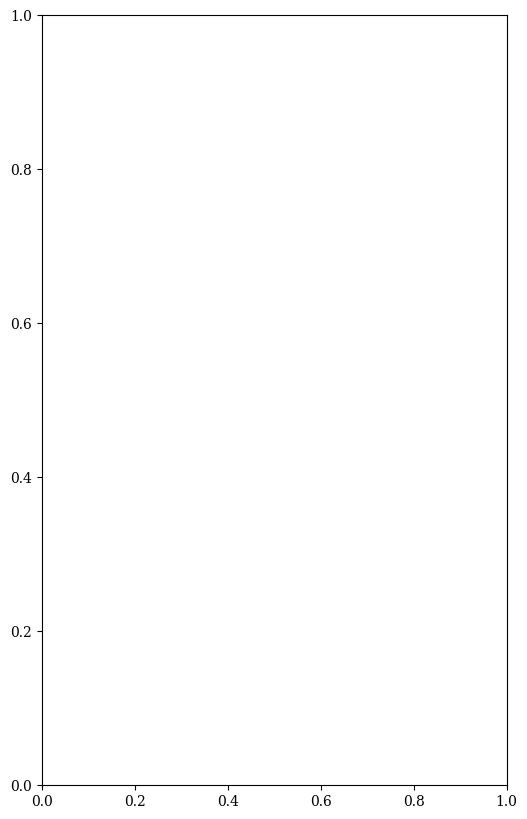

In [26]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='z')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('F1', 'f1')]

pc = ax.pcolormesh(test1, vmin=0, vmax=0.5,   rasterized=True) 
clb=fig.colorbar(pc, location='right',)

#clb.set_ticks([0,0.1,.3.14], labels=['','upwind','downwind'],rotation=270)

#clb.ax.set_title('Altitude (m)', loc='right')

ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','','3'])
#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)
#ax.set_xlabel('Time, s')
fifi.mpl_functions.set_fontsize(ax, 6)

#
layout.append_figure_to_layer(layout.figures['F1'], 'F1', cleartarget=True)

/tmp/ipykernel_7458/2088666145.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


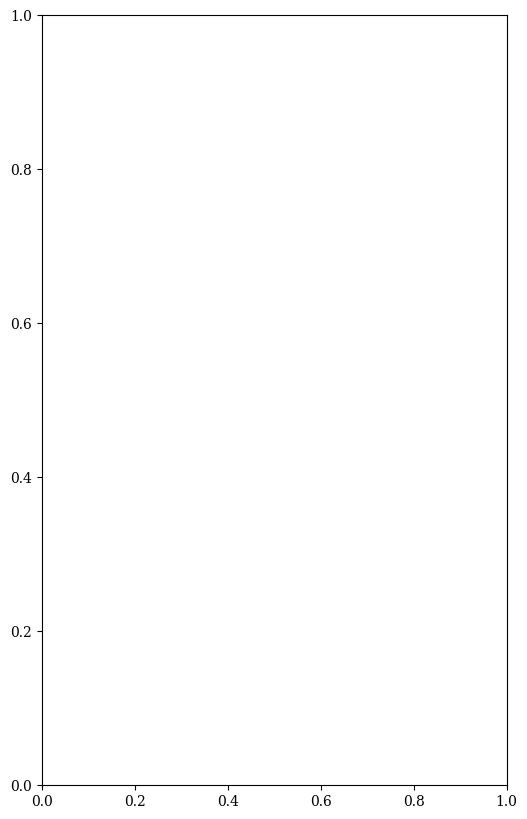

In [27]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='adj_heading')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('F2', 'f2')]

pc = ax.pcolormesh(test1, vmin=0, vmax=np.pi,   rasterized=True)
clb=fig.colorbar(pc, location='right')
clb.set_ticks([0,(np.pi/2),3.14], labels=['0','','$\pi$'])
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''],)
fifi.mpl_functions.set_fontsize(ax, 6)



layout.append_figure_to_layer(layout.figures['F2'], 'F2', cleartarget=True)

/tmp/ipykernel_7458/40952940.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


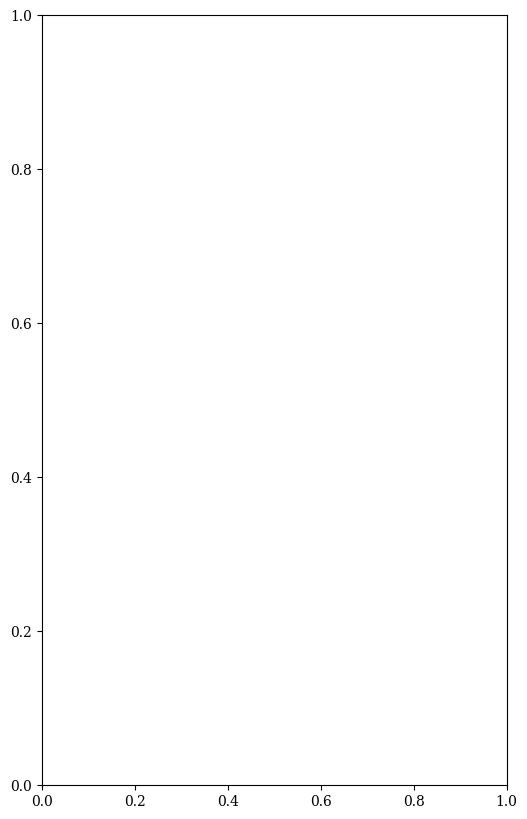

In [28]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='abs_smooth_ang_vel')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('F3', 'f3')]

pc = ax.pcolormesh(test1, vmin=0,vmax=20,  rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,3.14], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['F3'], 'F3', cleartarget=True)


/tmp/ipykernel_7458/1366359077.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


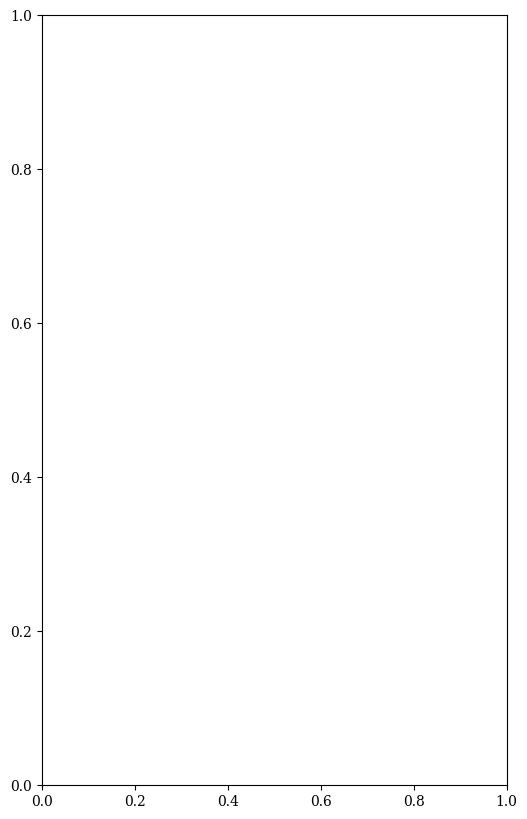

In [29]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='ground speed')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('F4', 'f4')]

pc = ax.pcolormesh(test1, vmin=0, vmax=1,   rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,1], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350], )
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['F4'], 'F4', cleartarget=True)

## Top Fans On

In [30]:
df_flash = df_flash_top_on
df_flash_triggers = df_flash[df_flash.obj_id_unique.isin(df_flash[df_flash.Trigger_bool==True].obj_id_unique.unique())]
df_flash_triggers = df_flash_triggers.groupby('obj_id_unique').filter(lambda d: d['time stamp'].max()>=3000)
df_flash_triggers['abs_smooth_ang_vel'] = np.abs(df_flash_triggers.smoothed_angvel_params_128)

In [31]:
dum_df = df_flash_triggers
df_flash_sorted_by_z = dum_df.sort_values(by='obj_id_unique', key=traj_sorter)
df_flash_sorted_by_z['adj_heading'] = np.abs(df_flash_sorted_by_z['heading'].copy())



In [32]:
#fix index for plotting
df_flash_sorted_by_z['new_index']=0
j=1
catch =[]
means = []
for i in df_flash_sorted_by_z.obj_id_unique.unique():
    dum = df_flash_sorted_by_z[ df_flash_sorted_by_z.obj_id_unique==i]
    dum['new_index'] = j 
    #print('index:'+ str(dum['new_index'].iloc[0]) + ', mean z:' + str(np.mean(dum[dum['time stamp'].between(0,675)].z)) )
    j+=1
    catch.append(dum)
    means.append(np.mean(dum[dum['time stamp'].between(0,675)].z))
df_flash_sorted_by_z=pd.concat(catch)   


/tmp/ipykernel_7458/1160298079.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dum['new_index'] = j


/tmp/ipykernel_7458/4233043248.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right',)


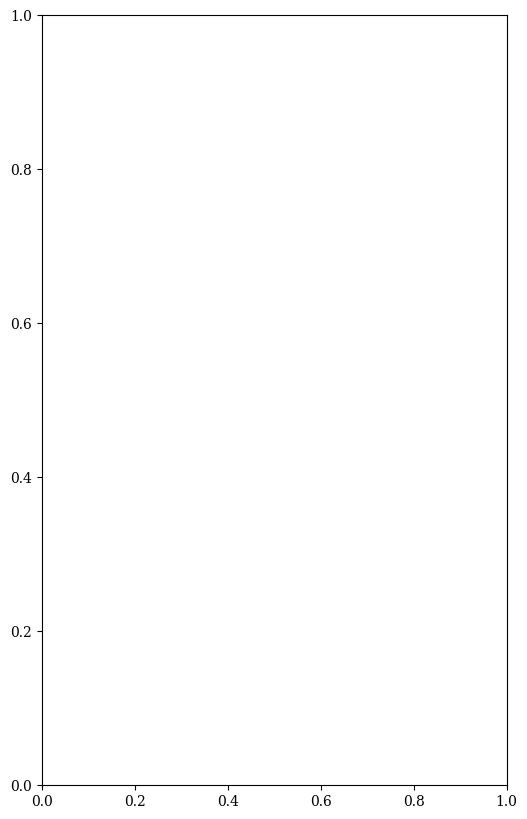

In [33]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='z')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('G1', 'g1')]

pc = ax.pcolormesh(test1, vmin=0, vmax=0.5,   rasterized=True) 
clb=fig.colorbar(pc, location='right',)

#clb.set_ticks([0,0.1,.3.14], labels=['','upwind','downwind'],rotation=270)

#clb.ax.set_title('Altitude (m)', loc='right')

ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','','3'])
#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)
#ax.set_xlabel('Time, s')
fifi.mpl_functions.set_fontsize(ax, 6)

#
layout.append_figure_to_layer(layout.figures['G1'], 'G1', cleartarget=True)

/tmp/ipykernel_7458/4198203991.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


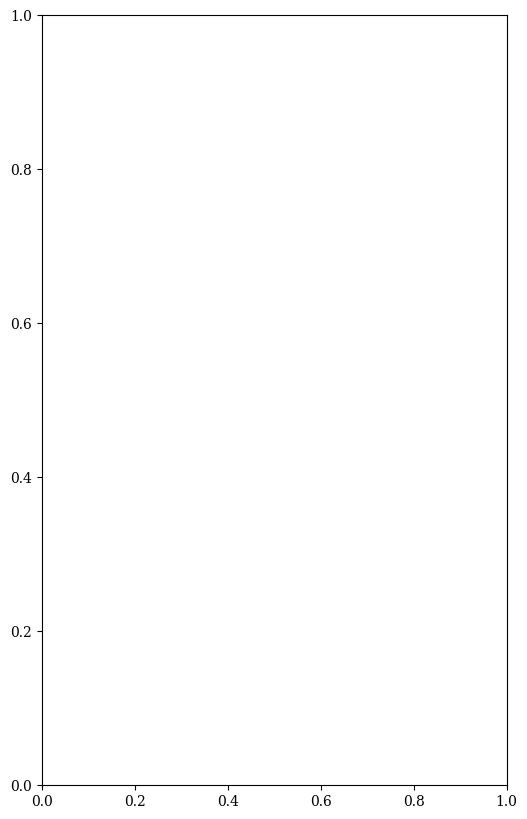

In [34]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='adj_heading')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('G2', 'g2')]

pc = ax.pcolormesh(test1, vmin=0, vmax=np.pi,   rasterized=True)
clb=fig.colorbar(pc, location='right')
clb.set_ticks([0,(np.pi/2),3.14], labels=['0','','$\pi$'])
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''],)
fifi.mpl_functions.set_fontsize(ax, 6)



layout.append_figure_to_layer(layout.figures['G2'], 'G2', cleartarget=True)

/tmp/ipykernel_7458/3083333357.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


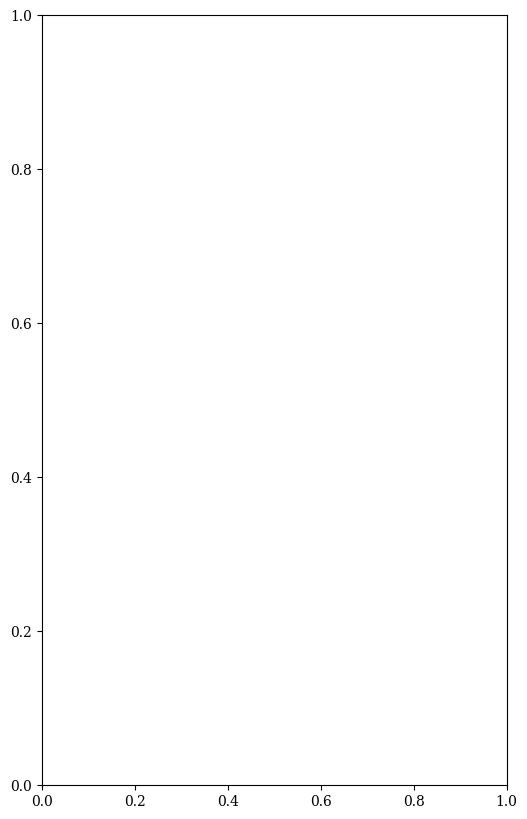

In [35]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='abs_smooth_ang_vel')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('G3', 'g3')]

pc = ax.pcolormesh(test1, vmin=0,vmax=20,  rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,3.14], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['G3'], 'G3', cleartarget=True)


/tmp/ipykernel_7458/1050736782.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


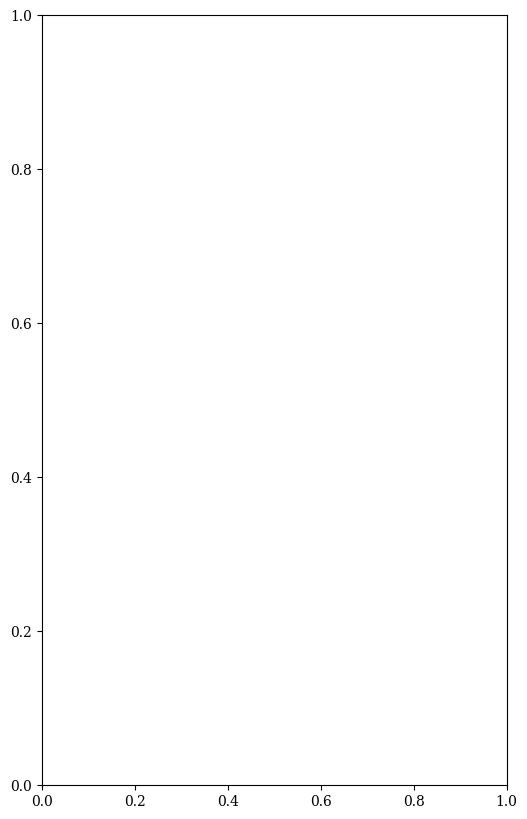

In [36]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='ground speed')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('G4', 'g4')]

pc = ax.pcolormesh(test1, vmin=0, vmax=1,   rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,1], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350], )
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['G4'], 'G4', cleartarget=True)

## Shams

In [37]:
df_sham_triggers = df_sham_top_on
#df_sham_triggers = df_sham[df_sham.obj_id_unique.isin(df_sham[df_sham.Trigger_bool==True].obj_id_unique.unique())]
df_sham_triggers = df_sham_triggers.groupby('obj_id_unique').filter(lambda d: d['time stamp'].max()>=3000)
df_sham_triggers['abs_smooth_ang_vel'] = np.abs(df_sham_triggers.smoothed_angvel_params_128)

In [38]:
dum_df = df_sham_triggers
df_sham_sorted_by_z = dum_df.sort_values(by='obj_id_unique', key=traj_sorter)
df_sham_sorted_by_z['adj_heading'] = np.abs(df_sham_sorted_by_z['heading'].copy())



In [39]:
#fix index for plotting
df_sham_sorted_by_z['new_index']=0
j=1
catch =[]
means = []
for i in df_sham_sorted_by_z.obj_id_unique.unique():
    dum = df_sham_sorted_by_z[ df_sham_sorted_by_z.obj_id_unique==i]
    dum['new_index'] = j 
    #print('index:'+ str(dum['new_index'].iloc[0]) + ', mean z:' + str(np.mean(dum[dum['time stamp'].between(0,675)].z)) )
    j+=1
    catch.append(dum)
    means.append(np.mean(dum[dum['time stamp'].between(0,675)].z))
df_sham_sorted_by_z=pd.concat(catch)    

/tmp/ipykernel_7458/623801160.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dum['new_index'] = j


/tmp/ipykernel_7458/2879833029.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right',)


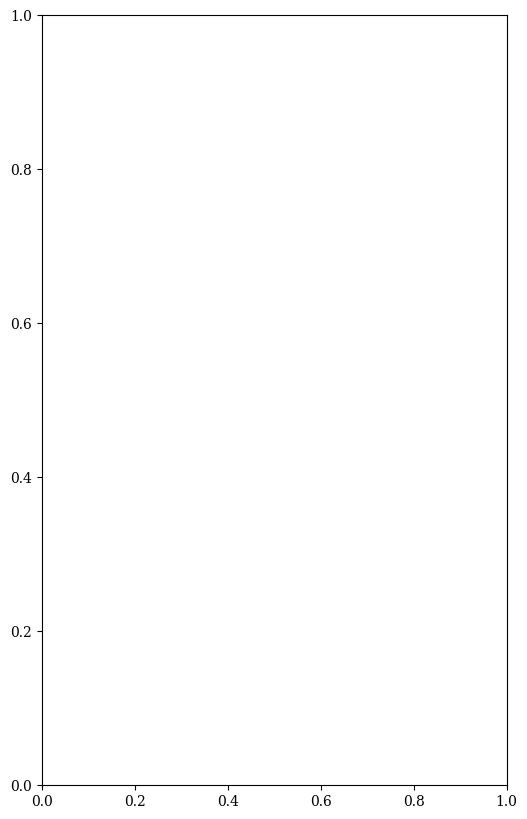

In [40]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='z')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('H1', 'h1')]

pc = ax.pcolormesh(test1, vmin=0, vmax=0.5,   rasterized=True) 
clb=fig.colorbar(pc, location='right',)

#clb.set_ticks([0,0.1,.3.14], labels=['','upwind','downwind'],rotation=270)

#clb.ax.set_title('Altitude (m)', loc='right')

ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','','3'])
#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)
#ax.set_xlabel('Time, s')
fifi.mpl_functions.set_fontsize(ax, 6)

#
layout.append_figure_to_layer(layout.figures['H1'], 'H1', cleartarget=True)

/tmp/ipykernel_7458/629670698.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


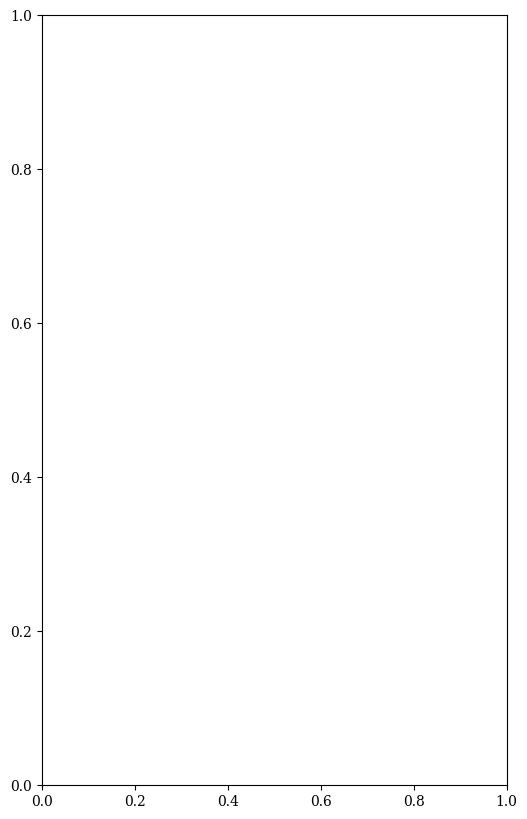

In [41]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='adj_heading')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('H2', 'h2')]

pc = ax.pcolormesh(test1, vmin=0, vmax=np.pi,   rasterized=True)
clb=fig.colorbar(pc, location='right')
clb.set_ticks([0,(np.pi/2),3.14], labels=['0','','$\pi$'])
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''],)
fifi.mpl_functions.set_fontsize(ax, 6)



layout.append_figure_to_layer(layout.figures['H2'], 'H2', cleartarget=True)

/tmp/ipykernel_7458/2165226425.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


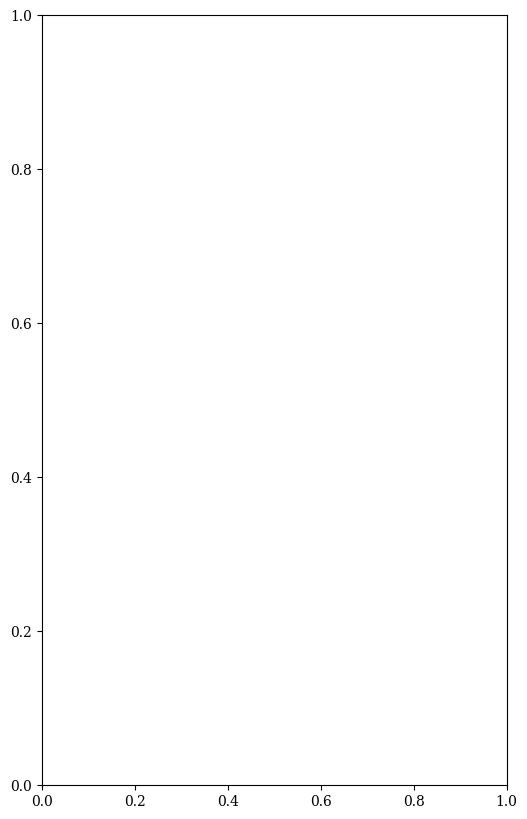

In [42]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='abs_smooth_ang_vel')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('H3', 'h3')]

pc = ax.pcolormesh(test1, vmin=0,vmax=20,  rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,3.14], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['H3'], 'H3', cleartarget=True)


/tmp/ipykernel_7458/4071309980.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


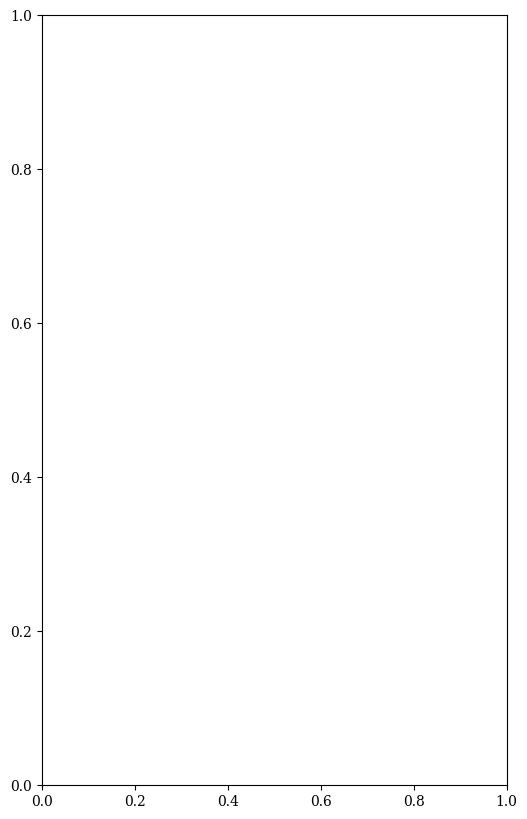

In [43]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='ground speed')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('H4', 'h4')]

pc = ax.pcolormesh(test1, vmin=0, vmax=1,   rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,1], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

#ax.set_yticks([0,500,1000])
#ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350], )
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['H4'], 'H4', cleartarget=True)

In [ ]:
layout.write_svg('supp_all_trajectories_altitude_sorted_pca.svg')